# Notebook 03 — Rubber Band Segmentation & Edge Detection

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 3:** Intensity-based segmentation → clean binary mask → Canny on mask edges

**Input:**
- Rectified images from `outputs/02_rectified/`
- Calibration data from `outputs/02_rectified/calibration.json`

**Output:**
- Binary edge maps saved to `outputs/03_canny/`

**Key idea:** The rubber band is dark and the table background is white/light.
Instead of applying Canny directly on the raw image (which picks up all internal
texture), we first segment the rubber band by intensity thresholding to get a
clean binary mask, then apply Canny on that mask. This way Canny only detects
the outer contours of the rubber band, which is where the cut edges are.

## 1. Imports and configuration

In [51]:
%pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [53]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")
CALIB_PATH    = RECTIFIED_DIR / "calibration.json"
OUTPUT_DIR    = Path("outputs/03_canny")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Segmentation parameters ────────────────────────────────────────────────
# Light blur before thresholding to reduce noise
GAUSSIAN_KERNEL   = (5, 5)
GAUSSIAN_SIGMA    = 0

# Intensity threshold: pixels below this are rubber (dark), above are background (light)
# Set to None to use Otsu automatically, or a fixed int (e.g. 100) for manual control
INTENSITY_THR     = None   # None = automatic Otsu

# Morphological closing: fills small holes inside the rubber mask
# Increase if the mask has gaps; decrease if it merges separate objects
MORPH_KERNEL_SIZE = 5

# ── Canny parameters ───────────────────────────────────────────────────────
# Applied on the clean binary mask — fixed thresholds are fine here
# because the mask is already binary (0 or 255)
CANNY_T_LOW  = 50
CANNY_T_HIGH = 150

# Load calibration
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)

print(f"Rectified dir  : {RECTIFIED_DIR.resolve()}")
print(f"Output dir     : {OUTPUT_DIR.resolve()}")
print(f"Calibrated imgs: {len(calibration_data)}")

Rectified dir  : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Output dir     : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Calibrated imgs: 22


## 2. Intensity-based segmentation

The rubber band is significantly darker than the white table background.
A simple intensity threshold reliably separates the two regions.
Morphological closing fills small holes caused by reflections or worn areas.

In [54]:
def segment_rubber_band(img_bgr: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Segment the rubber band from the background using intensity thresholding.

    Parameters
    ----------
    img_bgr : np.ndarray — rectified BGR image

    Returns
    -------
    mask    : np.ndarray — binary mask (255 = rubber, 0 = background)
    blurred : np.ndarray — grayscale blurred image (for reference)
    thr     : float — threshold value used
    """
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, GAUSSIAN_KERNEL, GAUSSIAN_SIGMA)

    if INTENSITY_THR is None:
        # Automatic: Otsu finds the best threshold between dark rubber and light background
        thr, mask = cv2.threshold(blurred, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        thr = float(INTENSITY_THR)
        _, mask = cv2.threshold(blurred, INTENSITY_THR, 255, cv2.THRESH_BINARY)

    # Morphological closing: fill internal holes in the rubber mask
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask, blurred, float(thr)

## 3. Canny on the clean mask

Applying Canny on the binary mask instead of the raw image means we only
detect the outer contours of the rubber band segments, eliminating all
internal texture noise.

In [55]:
def detect_edges(mask: np.ndarray) -> np.ndarray:
    """
    Apply Canny edge detection on the binary rubber band mask.

    Since the mask is already binary, fixed thresholds work well here.

    Parameters
    ----------
    mask : np.ndarray — binary mask (255 = rubber)

    Returns
    -------
    edges : np.ndarray — binary edge map
    """
    edges = cv2.Canny(mask, CANNY_T_LOW, CANNY_T_HIGH)
    return edges

## 4. Full pipeline per image

In [56]:
def process_image(image_name: str) -> dict | None:
    img = cv2.imread(str(RECTIFIED_DIR / image_name))
    if img is None:
        print(f"  [SKIP] {image_name}")
        return None

    mask, blurred, thr = segment_rubber_band(img)
    edges              = detect_edges(mask)

    cv2.imwrite(str(OUTPUT_DIR / image_name), edges)

    return {
        'image_name'   : image_name,
        'threshold'    : thr,
        'mask_coverage': float(np.mean(mask > 0)),
        'edge_density' : float(np.mean(edges > 0))
    }

In [57]:
canny_results = {}

for image_name in calibration_data:
    result = process_image(image_name)
    if result is not None:
        canny_results[image_name] = result
        print(f"  [OK] {image_name:30s}  "
              f"thr={result['threshold']:5.1f}  "
              f"mask={result['mask_coverage']:.3f}  "
              f"edge_density={result['edge_density']:.4f}")

print(f"\nProcessed {len(canny_results)} / {len(calibration_data)} images")

  [OK] Multimedia_31.jpg               thr=128.0  mask=0.433  edge_density=0.0054
  [OK] Multimedia_32.jpg               thr=123.0  mask=0.431  edge_density=0.0056
  [OK] Multimedia_33.jpg               thr=124.0  mask=0.429  edge_density=0.0057
  [OK] Multimedia_34.jpg               thr=127.0  mask=0.445  edge_density=0.0060
  [OK] Multimedia_35.jpg               thr= 80.0  mask=0.036  edge_density=0.0004
  [OK] Multimedia_36.jpg               thr= 88.0  mask=0.163  edge_density=0.0014
  [OK] Multimedia_37.jpg               thr=103.0  mask=0.138  edge_density=0.0026
  [OK] Multimedia_38.jpg               thr= 97.0  mask=0.596  edge_density=0.0032
  [OK] Multimedia_39.jpg               thr=124.0  mask=0.448  edge_density=0.0065
  [OK] Multimedia_40.jpg               thr=123.0  mask=0.299  edge_density=0.0046
  [OK] Multimedia_41.jpg               thr=164.0  mask=0.462  edge_density=0.0082
  [OK] Multimedia_42.jpg               thr=127.0  mask=0.396  edge_density=0.0055
  [OK] Multimedi

## 5. Visual inspection

Shows the 4 stages: original → grayscale blur → rubber mask → edge map

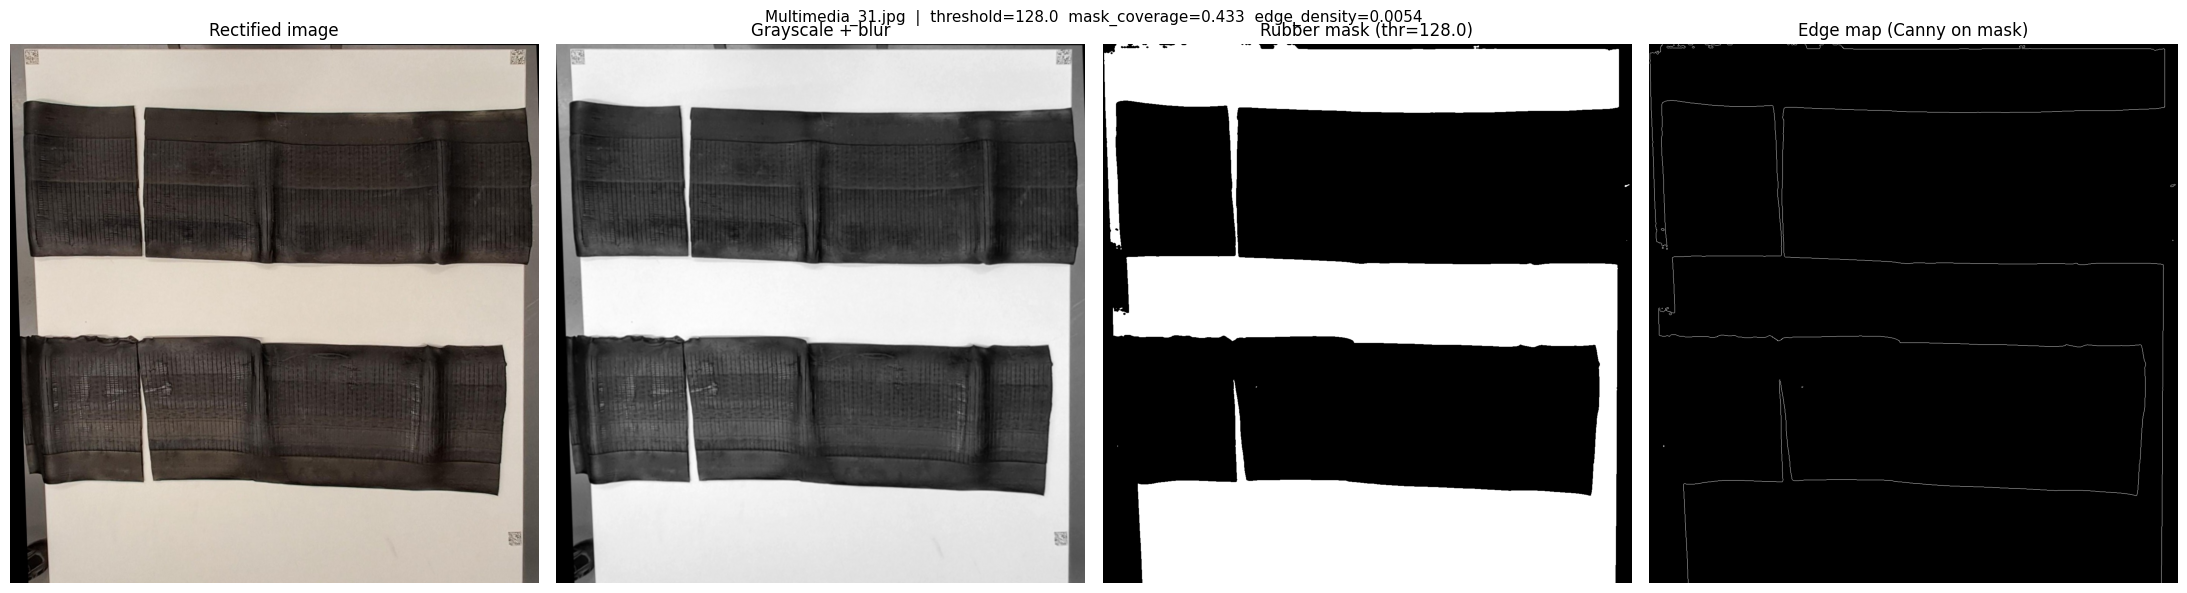

In [58]:
def visualize(image_name: str):
    img                = cv2.imread(str(RECTIFIED_DIR / image_name))
    mask, blurred, thr = segment_rubber_band(img)
    edges              = detect_edges(mask)
    img_rgb            = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(f"{image_name}  |  threshold={thr:.1f}  "
                 f"mask_coverage={np.mean(mask>0):.3f}  "
                 f"edge_density={np.mean(edges>0):.4f}", fontsize=11)

    axes[0].imshow(img_rgb)
    axes[0].set_title("Rectified image")
    axes[0].axis("off")

    axes[1].imshow(blurred, cmap="gray")
    axes[1].set_title("Grayscale + blur")
    axes[1].axis("off")

    axes[2].imshow(mask, cmap="gray")
    axes[2].set_title(f"Rubber mask (thr={thr:.1f})")
    axes[2].axis("off")

    axes[3].imshow(edges, cmap="gray")
    axes[3].set_title("Edge map (Canny on mask)")
    axes[3].axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"check_{image_name}", dpi=120)
    plt.show()


visualize(next(iter(canny_results)))

In [59]:
# Visualize a different image — uncomment and change name
# visualize("Multimedia_42.jpg")

## 6. Diagnostics across all images

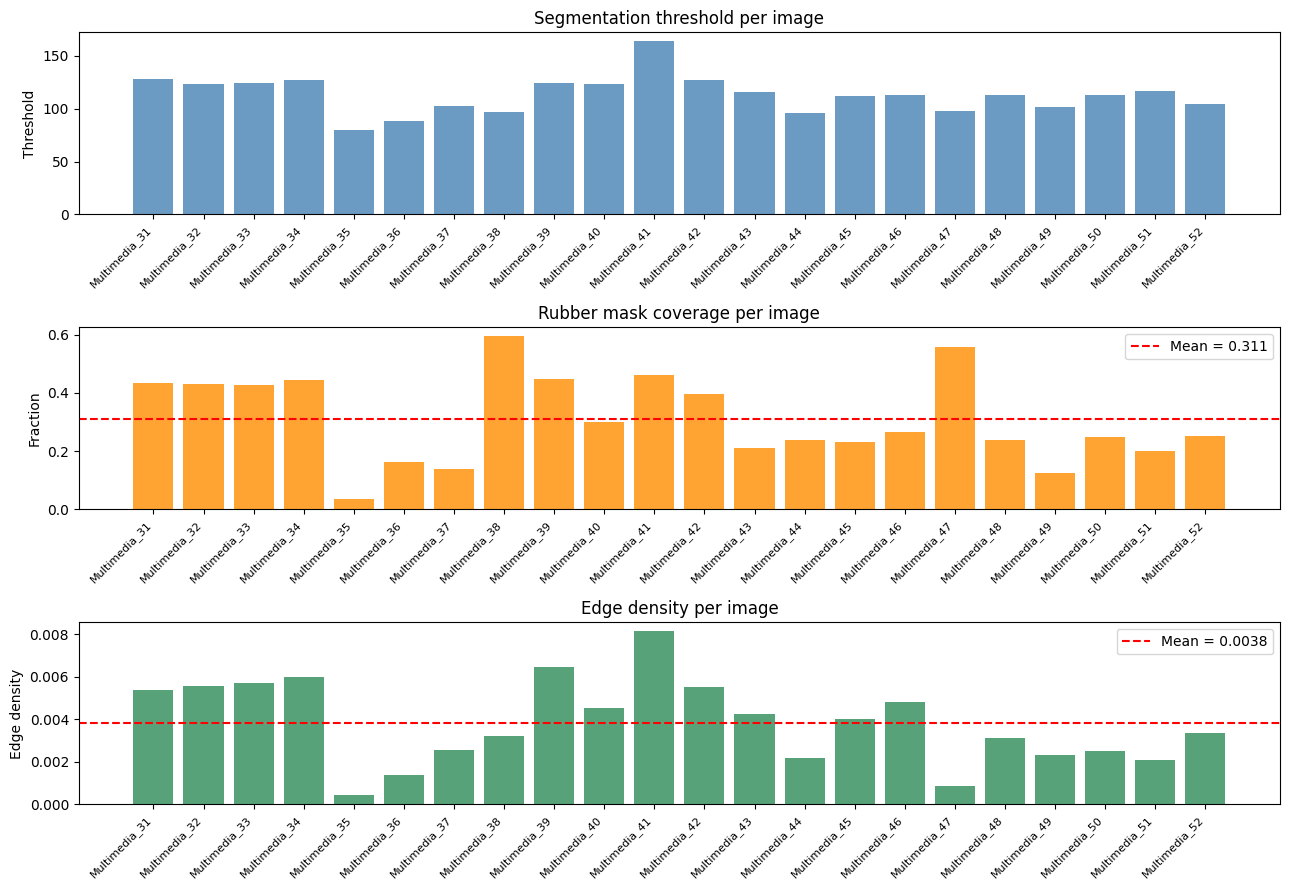

In [60]:
names     = list(canny_results.keys())
thrs      = [canny_results[n]['threshold']     for n in names]
coverages = [canny_results[n]['mask_coverage'] for n in names]
densities = [canny_results[n]['edge_density']  for n in names]

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
x = range(len(names))
xlabels = [n.replace('.jpg', '') for n in names]

axes[0].bar(x, thrs, color='steelblue', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Threshold'); axes[0].set_title('Segmentation threshold per image')

axes[1].bar(x, coverages, color='darkorange', alpha=0.8)
axes[1].axhline(np.mean(coverages), color='red', linestyle='--',
                label=f'Mean = {np.mean(coverages):.3f}')
axes[1].set_xticks(x); axes[1].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Fraction'); axes[1].set_title('Rubber mask coverage per image')
axes[1].legend()

axes[2].bar(x, densities, color='seagreen', alpha=0.8)
axes[2].axhline(np.mean(densities), color='red', linestyle='--',
                label=f'Mean = {np.mean(densities):.4f}')
axes[2].set_xticks(x); axes[2].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Edge density'); axes[2].set_title('Edge density per image')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'segmentation_diagnostics.png', dpi=150)
plt.show()

## 7. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 3a | Grayscale + Gaussian blur | kernel=(5,5) |
| 3b | Intensity threshold | Otsu automatic (THRESH_BINARY_INV) |
| 3c | Morphological closing | ellipse kernel 20×20 |
| 3d | Canny on mask | t_low=50, t_high=150 |

**Tuning tips:**
- If the mask includes too much background → lower `INTENSITY_THR` or set it manually
- If the mask has holes inside the rubber → increase `MORPH_KERNEL_SIZE`
- If the mask merges both rubber bands into one blob → decrease `MORPH_KERNEL_SIZE`

**Output folder:** `outputs/03_canny/`  
**Next notebook:** `04_hough.ipynb` — ROI, Hough Transform, geometric filtering